# Visión por computador MIA-B
# Entrega ejercicio práctico clase 2 - Grupo 3

**Fecha:** 2026-03-16  
**Versión:** 1.0

## Descripción
El presente documento tiene por objetivo presentar la tarea corespondencia a la **Clase 2**

## Autores:
 - Calahorrano Geovanna
 - Yanez Carlos
 - Vega Ivan

## Actividad individual calificable:

En esta actividad, llevaremos a cabo una serie de pruebas para evaluar la capacidad de nuestro modelo de clasificación de imágenes. El objetivo es identificar correctamente si una imagen contiene el rostro de un estudiante específico o si pertenece a un fondo. Para ello, hemos definido dos etiquetas principales:

##### **Label 1:** `Charlie`  
##### **Label 2:** `Fondo` (imagenes que no contengan el rostro del estudiante)

#### **Pruebas:**

Las pruebas se realizarán con diferentes tipos de imágenes de entrada para verificar la precisión del modelo en escenarios no vistos durante el entrenamiento:

1. **Input image:** Foto del estudiante que no se encuentre en la carpeta de entrenamiento (tómate una foto el día de la presentación usando tu webcam).
**Required output label:** `Nombre del estudiante`

2. **Input image:** Fondo que no se encuentre en la carpeta de entrenamiento (el estudiante que presente antes de ti te dará la palabra de búsqueda, puedes descargarla de Google Images).  
**Required output label:** `Fondo`
3. **Input image:** Foto de un rostro diferente al rostro del estudiante que no se encuentre en las carpetas de entrenamiento (el estudiante que presente antes de ti te dará un nombre de una celebridad que se parezca a ti, puedes descargarla de Google Images).  
**Required output label:** `Fondo`

##### **Hyperparameter testing (Opcional):**

Además, puedes explorar el impacto de varios hiperparámetros en el rendimiento del modelo. Los hiperparámetros a ajustar incluyen:

-Aumento de imágenes en la base de datos  
-Cambio de función de pérdida (loss)  
-Cambio en el optimizador (optimizer)  
-Cambio en el número de épocas de entrenamiento (epochs)  
-Cambio en el número de tamaño de lote (batch_size)

Estas pruebas y ajustes te permitirán optimizar el modelo para obtener la mejor precisión posible en la clasificación de imágenes.

##### **Presentación de resultados**

Los estudiantes presentarán sus resultados en clase usando una app de `streamlit`. La calificación dependerá del éxito de las 3 pruebas.

### Configuración del Entorno

In [2]:
%pip install ipykernel
%pip install opencv-python
%pip install keras
%pip install scikit-learn
%pip install tensorflow
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

#Librerias para obtener el path de un archivo
from tkinter import Tk
from tkinter.filedialog import askopenfilename

from sklearn.model_selection import train_test_split

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

SEED = 42
np.random.seed(SEED)

### Cargamos las imágenes del estudiante y de los fondos aleatorios

In [2]:
def get_face_detector():
    return cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

def crop_largest_face(img, face_detector, min_size=(50, 50), margin=0.15):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=min_size, flags=cv2.CASCADE_SCALE_IMAGE)

    if len(faces) == 0:
        return None

    # Elegimos el rostro más grande para enfocarnos en rasgos principales
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])

    mx = int(w * margin)
    my = int(h * margin)

    x1 = max(0, x - mx)
    y1 = max(0, y - my)
    x2 = min(img.shape[1], x + w + mx)
    y2 = min(img.shape[0], y + h + my)

    return img[y1:y2, x1:x2]

def load_images_from_folder(folder: Path, label: int, face_detector, image_size=(224, 224), use_face_crop=True):
    images = []
    labels = []

    for filename in os.listdir(folder):
        image_path = folder / filename
        img = cv2.imread(str(image_path))

        if img is None:
            continue

        # Para aprender rasgos faciales, priorizamos crop de rostro en clase estudiante
        if use_face_crop:
            face_img = crop_largest_face(img, face_detector)
            if face_img is None:
                continue
            img = face_img

        img = cv2.resize(img, image_size)
        img = preprocess_input(img.astype(np.float32))

        images.append(img)
        labels.append(label)

    return images, labels

face_detector = get_face_detector()

dataset_dir = Path.cwd().parent / "dataset"
student_dir = dataset_dir / "student"
background_dir = dataset_dir / "background"

if not student_dir.exists() or not background_dir.exists():
    raise FileNotFoundError(f"No se encontraron carpetas esperadas en: {dataset_dir}")

# Student: entrenamos con rostro detectado
student_images, student_labels = load_images_from_folder(student_dir, label=1, face_detector=face_detector, use_face_crop=True)

# Background: mantenemos imagen completa (sin rostro forzado)
background_images, background_labels = load_images_from_folder(background_dir, label=0, face_detector=face_detector, use_face_crop=False)

images = np.array(student_images + background_images, dtype=np.float32)
labels = np.array(student_labels + background_labels, dtype=np.float32)

print(f"Total imágenes válidas: {len(images)}")
print(f"Student: {int(np.sum(labels == 1))}, Background: {int(np.sum(labels == 0))}")

Total imágenes válidas: 28
Student: 14, Background: 14


In [3]:
from keras.utils import to_categorical

# One-hot encoding de las etiquetas
labels = to_categorical(labels) # Convertimos las etiquetas a formato one-hot encoding. Las etiquetas originales eran 0 y 1, y ahora se convierten en vectores binarios.
labels

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

Dividmos los datos en conjuntos de entrenamiento y prueba:

In [4]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2)
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (22, 224, 224, 3) (22, 2)
Test: (6, 224, 224, 3) (6, 2)


Construimos y entrenamos la red neuronal convolucional VGG-16:

In [5]:
# Definimos el callback de EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10)

# Cargamos la red VGG16, asegurándonos de que se dejan fuera las capas superiores de la red preentrenada (head FC layer)
baseModel = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Construimos la capa que se colocará en la parte superior del modelo base (baseModel)
model = Sequential()
model.add(baseModel)
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))  # Agregamos una capa de Dropout con una tasa de 0.5
model.add(Dense(2, activation='softmax'))  # Dos clases (perro y gato), por lo que la capa de salida tiene 2 neuronas

# Congelamos las capas del modelo base para que no se actualicen durante el entrenamiento
for layer in baseModel.layers:
    layer.trainable = False

# Compilamos el modelo 
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Entrenamos el modelo
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=300, batch_size=32, callbacks=[early_stopping])

# Evaluamos el modelo
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss: {loss}')
print(f'Accuracy: {accuracy}')

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5455 - loss: 4.9580 - val_accuracy: 0.8333 - val_loss: 7.7201
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9091 - loss: 2.4761 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 1.0837e-08 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - 

**Opcional:** Guardamos el modelo en un archivo formato .h5 y lo cargamos en el dispositivo de despliegue

In [6]:
# Exportamos en modelo en un formato .h5
model.save('classification_model_student_background.h5')

In [7]:
# Cargamos el modelo desde un archivo formato .h5
from keras.models import load_model
model = load_model('C:\\Users\\cyanezru\\OneDrive - NTT DATA EMEAL\\Documentos\\Repositories\\Vision-por-computador-MIA-B---Grupo-3\\Clase_2\\code\\classification_model_student_background.h5')

Hacemos una predicción con una nueva imagen para comprobar que el modelo funciona

In [13]:
Tk().withdraw()
file_path = askopenfilename(title="Seleccione un archivo")
print("Archivo seleccionado:", file_path)

# Cargar imagen
try:
    # Leemos una imagen nunca vista por el modelo utilizando OpenCV
    img = cv2.imread(file_path)

    # Redimensionamos la imagen a 224x224 píxeles para que coincida con la dimensión de entrada del modelo VGG-16
    img = cv2.resize(img, (224, 224))

    # Expandimos las dimensiones de la imagen para que tenga la forma (1, 224, 224, 3)
    # Esto es necesario porque el modelo espera un lote de imágenes como entrada
    img = np.expand_dims(img, axis=0)

    # Realizamos la predicción utilizando el modelo cargado
    pred = model.predict(img)

    # Imprimimos la predicción
    print(pred)

except FileNotFoundError:
    print("Error: no se encontró la imagen. Verifique la ruta.")

Archivo seleccionado: C:/Users/cyanezru/OneDrive - NTT DATA EMEAL/Documentos/Repositories/Vision-por-computador-MIA-B---Grupo-3/Clase_2/dataset/000016.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
[[1. 0.]]


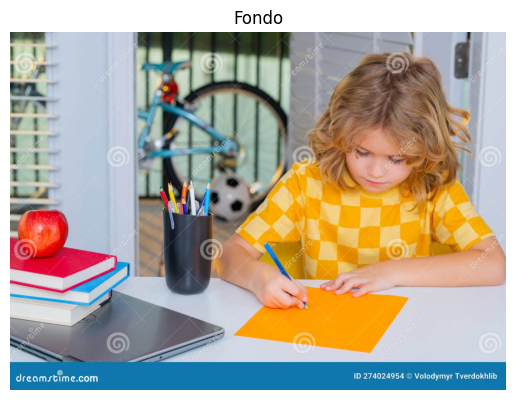

In [14]:
# Leemos una imagen nunca vista por el modelo utilizando OpenCV
img = cv2.imread(file_path)

# Convertimos la imagen de BGR (formato por defecto de OpenCV) a RGB (formato utilizado por Matplotlib)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# Comprobamos cuál de las dos probabilidades es mayor en la predicción
if pred[0][0] > pred[0][1]:
    # Si la probabilidad de que sea un fondo es mayor, imprimimos 'Fondo'
    plt.title('Fondo')
else:
    # Si la probabilidad de que sea un estudiante es mayor, imprimimos 'Charlie'
    plt.title('Charlie')

# Ocultamos los ejes de la imagen
plt.axis('off')  # Ocultamos los ejes
# Mostramos la imagen con la predicción
plt.show()

In [10]:
def take_photo(filename):
    # 1. Inicializar la cámara (0 es la cámara por defecto)
    cap = cv2.VideoCapture(0)
    saved_path = None

    if not cap.isOpened():
        print("Error: No se pudo acceder a la cámara.")
        return None

    print("Cámara abierta. Presiona 's' para guardar una foto o 'q' para salir.")

    try:
        while True:
            # 2. Leer un frame de la cámara
            ret, frame = cap.read()
            if not ret:
                print("Error al capturar el video.")
                break

            # 3. Mostrar el video en vivo en una ventana
            cv2.imshow('Presiona S para tomar foto', frame)

            # 4. Escuchar el teclado
            key = cv2.waitKey(1) & 0xFF
            if key == ord('s'):  # Si presiona 's', guarda la imagen
                output_path = Path(filename).resolve()
                ok = cv2.imwrite(str(output_path), frame)
                if ok:
                    saved_path = str(output_path)
                    print(f"¡Foto guardada como {saved_path}!")
                else:
                    print("No se pudo guardar la imagen.")
                break
            elif key == ord('q'):  # Si presiona 'q', sale sin guardar
                break
    finally:
        # 5. Liberar la cámara y cerrar ventanas
        cap.release()
        cv2.destroyAllWindows()

    return saved_path

In [11]:
filename_path = take_photo("foto_capturada.jpg")
if filename_path is not None:
    print(f"Foto guardada en: {filename_path}")
else:
    print("No se guardó ninguna foto.")
# Cargar imagen
try:
    # Leemos una imagen nunca vista por el modelo utilizando OpenCV
    img = cv2.imread(filename_path)

    # Redimensionamos la imagen a 224x224 píxeles para que coincida con la dimensión de entrada del modelo VGG-16
    img = cv2.resize(img, (224, 224))

    # Expandimos las dimensiones de la imagen para que tenga la forma (1, 224, 224, 3)
    # Esto es necesario porque el modelo espera un lote de imágenes como entrada
    img = np.expand_dims(img, axis=0)

    # Realizamos la predicción utilizando el modelo cargado
    pred = model.predict(img)

    # Imprimimos la predicción
    print(pred)

except FileNotFoundError:
    print("Error: no se encontró la imagen. Verifique la ruta.")


Cámara abierta. Presiona 's' para guardar una foto o 'q' para salir.
¡Foto guardada como C:\Users\cyanezru\OneDrive - NTT DATA EMEAL\Documentos\Repositories\Vision-por-computador-MIA-B---Grupo-3\Clase_2\code\foto_capturada.jpg!
Foto guardada en: C:\Users\cyanezru\OneDrive - NTT DATA EMEAL\Documentos\Repositories\Vision-por-computador-MIA-B---Grupo-3\Clase_2\code\foto_capturada.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
[[0. 1.]]


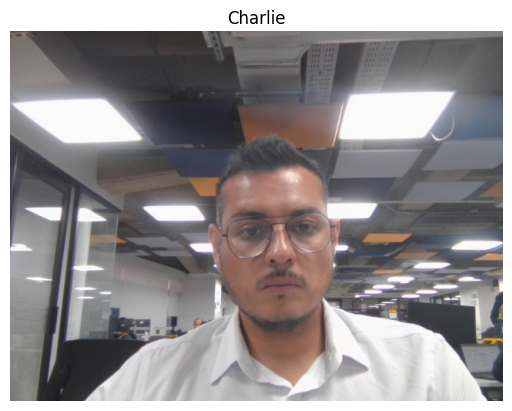

In [12]:
# Leemos una imagen nunca vista por el modelo utilizando OpenCV
img = cv2.imread(filename_path)

# Convertimos la imagen de BGR (formato por defecto de OpenCV) a RGB (formato utilizado por Matplotlib)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# Comprobamos cuál de las dos probabilidades es mayor en la predicción
if pred[0][0] > pred[0][1]:
    # Si la probabilidad de que sea un fondo es mayor, imprimimos 'Fondo'
    plt.title('Fondo')
else:
    # Si la probabilidad de que sea un estudiante es mayor, imprimimos 'Charlie'
    plt.title('Charlie')

# Ocultamos los ejes de la imagen
plt.axis('off')  # Ocultamos los ejes
# Mostramos la imagen con la predicción
plt.show()

## Repositorio GIT

https://github.com/chalisin/Vision-por-computador-MIA-B---Grupo-3.git